In [1]:
import os
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stat
import pingouin as pg
import warnings
import statsmodels.formula.api as smf
warnings.filterwarnings('ignore')

In [2]:
os.chdir("C:/Experiments/audio_visual_socialfrommotion/exp1_replication_data")

In [3]:
experiment_df = pd.DataFrame()
demographic_df = pd.DataFrame()
sound_check_df = pd.DataFrame()
for id in os.listdir():
    data = json.load(open(id))          
    experiment  = pd.DataFrame(data["trials"])
    demographic = pd.DataFrame([data["demographics"]])
    sound_check = pd.DataFrame(data["soundCheck"])
    id = [experiment["id"][0]] * 3
    sound_check["id"] = id
    experiment_df = pd.concat([experiment_df, experiment], ignore_index=True)
    demographic_df = pd.concat([demographic_df, demographic], ignore_index=True)
    sound_check_df = pd.concat([sound_check_df, sound_check], ignore_index=True)


In [5]:
demographic_df['feedback'].unique()

array(['', 'None noteworthy. ', 'none', 'Thank you for the opportunity! ',
       'No', 'None. Thank you. ', 'no', 'No additional feedback',
       'mind juggling study', 'Nothing else. Thank you for the invite',
       'The study was very informative and entertaining.',
       'it was a fun experiment',
       'As the trials went on, sometimes my brain would get confused and forget what previous trials volumes had sounded like, so I would be unsure for a few trials of the volumes, then I would get back into it. I think my brain could only hold onto the volume comparisons for a certain number of trials before it started blending together and then I had to recalibrate.',
       'Thank you.',
       "got rather repetitive, feel like 3-4 trials would've sufficed",
       'Very repetitive.',
       'This study was VERY long and repetitive. Any way you could shorten it or make it more interesting?',
       'I would like to get to your attention that the task was too lengthy and took twice t

# survey

In [4]:
demographic_df[['coverstory', 'sound_awareness', 'speed_awareness']].value_counts()

coverstory  sound_awareness                             speed_awareness
children    Yes, sometimes louder and sometimes softer  Yes                74
            Yes, sometimes louder                       Yes                 9
balls       Yes, sometimes louder and sometimes softer  Yes                 5
children    No change noticed                           Yes                 4
animals     No change noticed                           Yes                 1
children    Yes, sometimes louder and sometimes softer  No                  1
            Yes, sometimes softer                       Yes                 1
magnet      No change noticed                           Yes                 1
Name: count, dtype: int64

## sound test

In [5]:
sound_check_df.head()

,pair,first_condition,second_condition,softer_position,response_position,correct,n_replays,rt,id
0,lower_vs_higher,lower,higher,1,1,1,0,3529,58adfc6e7cf56d0001f931a2
1,same_vs_lower,same,lower,2,2,1,0,2479,58adfc6e7cf56d0001f931a2
2,same_vs_higher,same,higher,1,1,1,0,3163,58adfc6e7cf56d0001f931a2
3,lower_vs_higher,higher,lower,2,2,1,0,6487,5a947fb0f05361000171b5a3
4,same_vs_lower,same,lower,2,2,1,0,4231,5a947fb0f05361000171b5a3


## exclusion

In [6]:
cover_drop = []
response_drop = []
sub_id = experiment_df['subject_id'].unique()

for i in sub_id:
    sub_demo = demographic_df[demographic_df['subject_id'] == i]
    if sub_demo['coverstory'].values[0] != 'children':
        cover_drop.append(i)
        
    sub_df = experiment_df[experiment_df['subject_id'] == i]
    if len(sub_df) != 162:
        response_drop.append(i)
    if len(sub_df[(sub_df['chargeSpeed'] == 9) & (sub_df['response'] == 'play')]) > len(sub_df[(sub_df['chargeSpeed'] == 1.5) & (sub_df['response'] == 'play')]):
        response_drop.append(i)
print("drop by coverstory", cover_drop)
print("drop by response", response_drop)

drop by coverstory ['58adfc6e7cf56d0001f931a2', '5a947fb0f05361000171b5a3', '6632e29a99699a0b259f5cdb', '66f0143ab60af2f164a772e2', '699d9b72bf2ee351dfa07356', '6a05eca31c02cac37913a741', '6a14d976147815cf904a30f7']
drop by response ['58adfc6e7cf56d0001f931a2', '5be9ce784f251d00015ce92e', '5fc3d41149c0c8728f07b95b', '667cfd0b827314cd6f7027c4']


In [7]:
drop = list(set(cover_drop + response_drop))
drop_set = set(drop)
kept_sub = [id for id in sub_id if id not in drop_set]

In [8]:
drop_set

{'58adfc6e7cf56d0001f931a2',
 '5a947fb0f05361000171b5a3',
 '5be9ce784f251d00015ce92e',
 '5fc3d41149c0c8728f07b95b',
 '6632e29a99699a0b259f5cdb',
 '667cfd0b827314cd6f7027c4',
 '66f0143ab60af2f164a772e2',
 '699d9b72bf2ee351dfa07356',
 '6a05eca31c02cac37913a741',
 '6a14d976147815cf904a30f7'}

In [9]:
# drop excluded subjects
experiment_df = experiment_df[~experiment_df['subject_id'].isin(drop_set)].reset_index(drop=True)
demographic_df = demographic_df[~demographic_df['subject_id'].isin(drop_set)].reset_index(drop=True)
sound_check_df = sound_check_df[~sound_check_df['id'].isin(drop_set)].reset_index(drop=True)
kept_id = experiment_df['id'].unique()

In [10]:
print("Number of kept subjects: ", len(kept_id))

Number of kept subjects:  86


## grouping by sound test

In [11]:
sound_check_wide = sound_check_df.pivot_table(index="id", columns="pair", values="correct", aggfunc="max")

sound_check_wide["perceives_higher"] = sound_check_wide["same_vs_higher"].eq(1)
sound_check_wide["perceives_lower"]  = sound_check_wide["same_vs_lower"].eq(1)

sound_check_wide["group"] = "neither"
sound_check_wide.loc[sound_check_wide["perceives_higher"] & sound_check_wide["perceives_lower"], "group"] = "both"
sound_check_wide.loc[sound_check_wide["perceives_higher"] & ~sound_check_wide["perceives_lower"], "group"] = "higher_only"
sound_check_wide.loc[~sound_check_wide["perceives_higher"] & sound_check_wide["perceives_lower"], "group"] = "lower_only"

sound_check_wide = sound_check_wide.reset_index()

both_ids        = sound_check_wide.loc[sound_check_wide["group"] == "both",        "id"].tolist()
higher_only_ids = sound_check_wide.loc[sound_check_wide["group"] == "higher_only", "id"].tolist()
lower_only_ids  = sound_check_wide.loc[sound_check_wide["group"] == "lower_only",  "id"].tolist()
neither_ids     = sound_check_wide.loc[sound_check_wide["group"] == "neither",     "id"].tolist()

sound_check_wide["group"].value_counts()

group
both           82
higher_only     2
lower_only      1
neither         1
Name: count, dtype: int64

# main analysis - across sound conditions

In [12]:
experiment_df.head()

,id,trial_number,trialID,soundCondition,chargeSpeed,leftColor,ISI_ms,repetition,response,is_fight,response_rt,confidence,confidence_rt,subject_id
0,5b72d3f8afce7600019fe275,1,0890b767-b394-4f89-aea1-c60cab7014af,higher,4.00,grey,526.2,9,fight,1,2034,59.500000,2047,5b72d3f8afce7600019fe275
1,5b72d3f8afce7600019fe275,2,fb491605-8f46-43ab-ba62-bfd86d95e4d6,lower,4.00,black,468.8,1,fight,1,1996,39.500000,1266,5b72d3f8afce7600019fe275
2,5b72d3f8afce7600019fe275,3,2fa02aa8-ef06-46e0-87af-9e3b7267ee79,same,6.50,grey,492.9,9,fight,1,1166,57.833333,1794,5b72d3f8afce7600019fe275
3,5b72d3f8afce7600019fe275,4,8e0deaa9-1ac5-4e69-817a-3204f157f360,higher,5.25,grey,498.1,6,fight,1,981,36.000000,1620,5b72d3f8afce7600019fe275
4,5b72d3f8afce7600019fe275,5,9f53cd68-f278-45d6-806a-74eeef55bbcc,same,4.00,grey,519.0,5,play,0,1204,54.833333,1353,5b72d3f8afce7600019fe275


## judgement

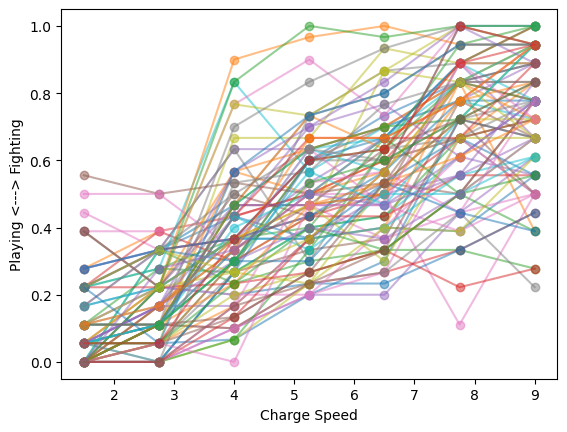

In [13]:
for id in kept_id:
    df = experiment_df[experiment_df['id'] == id]
    mean_rating_per_speed = pd.DataFrame(df.groupby('chargeSpeed')['is_fight'].mean().reset_index())
    plt.plot(mean_rating_per_speed['chargeSpeed'], mean_rating_per_speed['is_fight'], marker='o', alpha=0.5)
    plt.ylim(-0.05, 1.05)
    plt.xlabel('Charge Speed')
    plt.ylabel('Playing <---> Fighting')

Text(0, 0.5, 'Playing <---> Fighting')

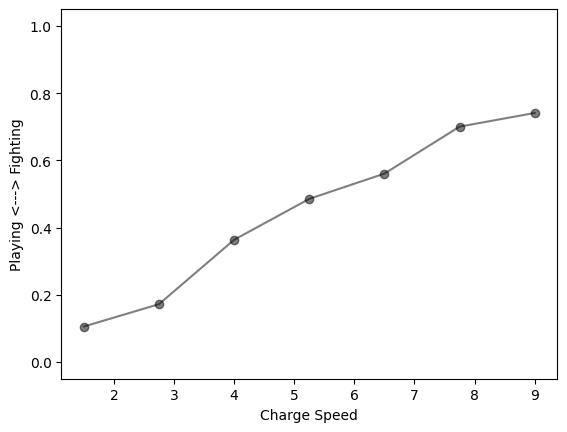

In [14]:
mean_judgement = pd.DataFrame(experiment_df.groupby('chargeSpeed')['is_fight'].mean().reset_index())
plt.plot(mean_judgement['chargeSpeed'], mean_judgement['is_fight'], color='black', marker='o', alpha=0.5)
plt.ylim(-0.05, 1.05)
plt.xlabel('Charge Speed')
plt.ylabel('Playing <---> Fighting')

In [15]:
mean_judgement

,chargeSpeed,is_fight
0,1.50,0.105297
1,2.75,0.171835
2,4.00,0.363566
3,5.25,0.485271
4,6.50,0.560465
5,7.75,0.700258
6,9.00,0.740956


Text(0, 0.5, 'Playing <---> Fighting')

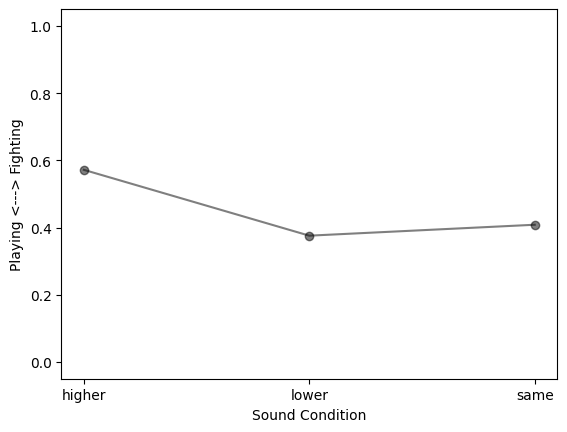

In [16]:
mean_judgementby_sound = pd.DataFrame(experiment_df.groupby('soundCondition')['is_fight'].mean().reset_index())
plt.plot(mean_judgementby_sound['soundCondition'], mean_judgementby_sound['is_fight'], color='black', marker='o', alpha=0.5)
plt.ylim(-0.05, 1.05)
plt.xlabel('Sound Condition')
plt.ylabel('Playing <---> Fighting')

In [17]:
mean_judgementby_sound

,soundCondition,is_fight
0,higher,0.571705
1,lower,0.375754
2,same,0.408269


In [18]:
id_mean = experiment_df.groupby(['id', 'soundCondition', 'chargeSpeed'])[['is_fight', 'confidence']].mean().reset_index()
id_mean.head()

,id,soundCondition,chargeSpeed,is_fight,confidence
0,5b72d3f8afce7600019fe275,higher,1.50,0.666667,29.777778
1,5b72d3f8afce7600019fe275,higher,2.75,1.000000,45.694444
2,5b72d3f8afce7600019fe275,higher,4.00,0.900000,47.533333
3,5b72d3f8afce7600019fe275,higher,5.25,1.000000,53.283333
4,5b72d3f8afce7600019fe275,higher,6.50,1.000000,67.233333


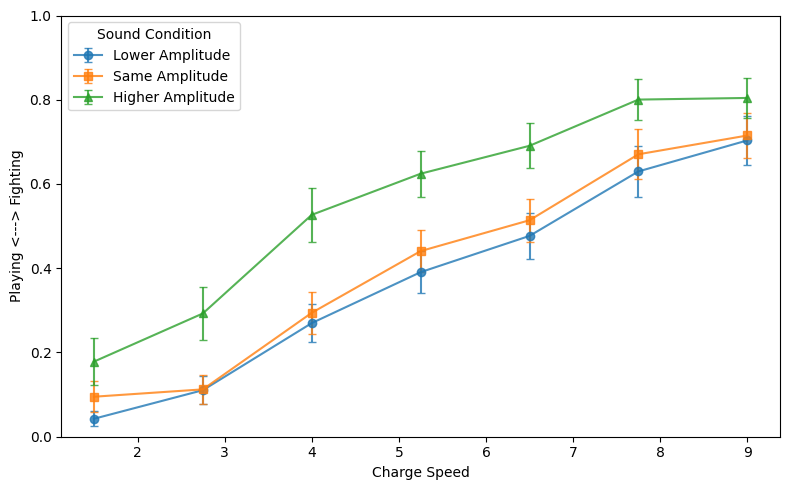

In [19]:
fig, ax = plt.subplots(figsize=(8, 5))

conditions = [
    ('lower',  'Lower Amplitude',  'o'),
    ('same',   'Same Amplitude',   's'),
    ('higher', 'Higher Amplitude', '^'),
]

subj = 'subject_id' 

for cond, label, marker in conditions:
    sub = experiment_df[experiment_df['soundCondition'] == cond]

    # per-subject proportion
    per_subj = (sub.groupby([subj, 'chargeSpeed'])['is_fight']
                   .mean().reset_index())

    agg = (per_subj.groupby('chargeSpeed')['is_fight']
                   .agg(m='mean', s='sem', n='count').reset_index())

    # 95% CI half-width via t (per speed, since n can vary)
    agg['ci'] = agg['s'] * stat.t.ppf(0.975, agg['n'] - 1)

    ax.errorbar(agg['chargeSpeed'], agg['m'], yerr=agg['ci'],
                marker=marker, capsize=3, alpha = 0.8, label=label)

ax.set_xlabel('Charge Speed')
ax.set_ylabel('Playing <---> Fighting')
ax.set_ylim(0, 1)
ax.legend(title='Sound Condition')
plt.tight_layout()
plt.show()

In [20]:
import pingouin as pg
anova = pg.rm_anova(dv='is_fight', within=['soundCondition', 'chargeSpeed'], subject='id', data=id_mean)
print(anova)

                         Source         SS  ddof1  ddof2         MS  \
0                soundCondition  11.787768      2    170   5.893884   
1                   chargeSpeed  93.996320      6    510  15.666053   
2  soundCondition * chargeSpeed   1.100561     12   1020   0.091713   

            F          p-unc     p-GG-corr       ng2       eps  
0   42.706300   9.387743e-16  2.176104e-11  0.105495  0.672713  
1  261.039702  6.282364e-152  4.857893e-66  0.484652  0.423717  
2    4.133517   2.388596e-06  4.391434e-03  0.010891  0.291425  


In [21]:
posthoc_sound = pg.pairwise_tests(
    dv='is_fight',
    within='soundCondition',
    subject='id',
    data=id_mean,
    padjust='bonf',
    effsize='cohen'
)
print(posthoc_sound)

         Contrast       A      B  Paired  Parametric         T   dof  \
0  soundCondition  higher  lower    True        True  7.065979  85.0   
1  soundCondition  higher   same    True        True  6.600861  85.0   
2  soundCondition   lower   same    True        True -2.550148  85.0   

  alternative         p-unc        p-corr p-adjust       BF10     cohen  
0   two-sided  4.117778e-10  1.235334e-09     bonf  2.428e+07  1.085624  
1   two-sided  3.336895e-09  1.001069e-08     bonf  3.268e+06  0.921746  
2   two-sided  1.256071e-02  3.768213e-02     bonf      2.489 -0.211467  


In [90]:
is_fight_per_condition = experiment_df.groupby(['soundCondition', 'chargeSpeed'])[['is_fight']].mean().reset_index().pivot(index='soundCondition', columns='chargeSpeed', values='is_fight')
d = is_fight_per_condition
diffs = pd.DataFrame({
    'up':   d.loc['higher'] - d.loc['same'],
    'down': d.loc['same']   - d.loc['lower'],
})
diffs['asym']  = diffs.up - diffs.down
diffs['ratio'] = diffs.up / diffs.down
print(diffs.round(3))
print(f"\nmean up = {diffs.up.mean():.3f}, mean down = {diffs.down.mean():.3f}, "
      f"ratio = {diffs.up.mean()/diffs.down.mean():.2f}")

                up   down   asym   ratio
chargeSpeed                             
1.50         0.083  0.052  0.031   1.593
2.75         0.180  0.002  0.178  93.000
4.00         0.233  0.024  0.208   9.524
5.25         0.184  0.050  0.134   3.674
6.50         0.177  0.037  0.140   4.750
7.75         0.130  0.041  0.089   3.190
9.00         0.089  0.012  0.078   7.667

mean up = 0.154, mean down = 0.031, ratio = 4.93


### intermediate speeds

In [22]:
wide = id_mean.pivot_table(index=["id", "chargeSpeed"],
                           columns="soundCondition",
                           values=["is_fight", "confidence"])

diff = pd.DataFrame({
    "is_fight_high_low":   wide[("is_fight",   "higher")] - wide[("is_fight",   "lower")],
    "is_fight_high_same":   wide[("is_fight",   "higher")] - wide[("is_fight",   "same")],
    "is_fight_low_same":   wide[("is_fight",   "lower")] - wide[("is_fight",   "same")],
    "confidence_high_low":   wide[("confidence",   "higher")] - wide[("confidence",   "lower")],
    "confidence_high_same":   wide[("confidence",   "higher")] - wide[("confidence",   "same")],
    "confidence_low_same":   wide[("confidence",   "lower")] - wide[("confidence",   "same")],
}).reset_index()

diff_mean = diff.groupby('chargeSpeed')[['is_fight_high_low', 'is_fight_high_same', 'is_fight_low_same', 'confidence_high_low', 'confidence_high_same', 'confidence_low_same']].mean().reset_index()

Text(0.5, 1.0, 'Higher - Lower')

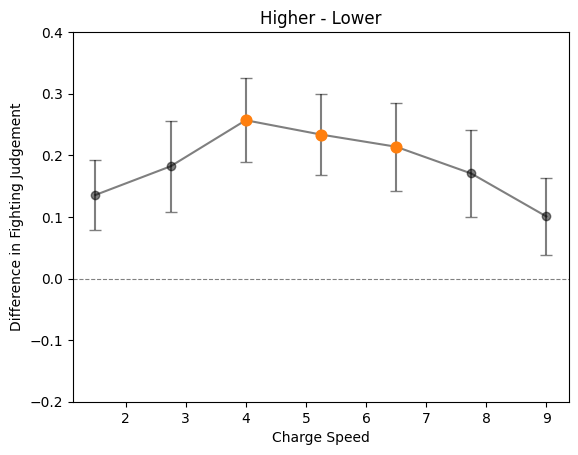

In [23]:
ci = diff.groupby('chargeSpeed')['is_fight_high_low'].agg(['sem', 'count'])
ci['ci95'] = ci['sem'] * stat.t.ppf(0.975, ci['count'] - 1)
diff_mean['ci95'] = ci['ci95'].values

mid = diff_mean['chargeSpeed'].isin([4, 5.25, 6.5])        

plt.axhline(0, color='gray', lw=0.8, ls='--')           
plt.errorbar(diff_mean['chargeSpeed'], diff_mean['is_fight_high_low'],
             yerr=diff_mean['ci95'], color='black', marker='o',
             alpha=0.5, capsize=4)                          
plt.scatter(diff_mean.loc[mid, 'chargeSpeed'], diff_mean.loc[mid, 'is_fight_high_low'],
            color='tab:orange', s=60, zorder=5)

plt.ylim(-0.2, 0.4)
plt.xlabel('Charge Speed')
plt.ylabel('Difference in Fighting Judgement')
plt.title('Higher - Lower')

In [24]:
diff["speed_class"] = diff["chargeSpeed"].isin([4.0, 5.25, 6.5]).map({True: "intermediate", False: "extreme"})

In [25]:
intermediate_extreme = pg.pairwise_tests(
    dv='is_fight_high_low',
    within='speed_class',
    subject='id',
    data=diff,
    padjust='bonf',
    effsize='cohen'
)
print(intermediate_extreme)

      Contrast        A             B  Paired  Parametric         T   dof  \
0  speed_class  extreme  intermediate    True        True -4.761549  85.0   

  alternative     p-unc      BF10   cohen  
0   two-sided  0.000008  2081.223 -0.3371  


Text(0.5, 1.0, 'Higher - Same')

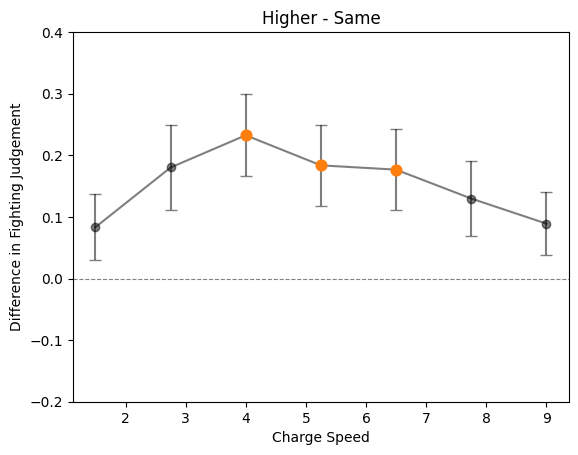

In [26]:
ci = diff.groupby('chargeSpeed')['is_fight_high_same'].agg(['sem', 'count'])
ci['ci95'] = ci['sem'] * stat.t.ppf(0.975, ci['count'] - 1)
diff_mean['ci95'] = ci['ci95'].values

mid = diff_mean['chargeSpeed'].isin([4, 5.25, 6.5])        

plt.axhline(0, color='gray', lw=0.8, ls='--')           
plt.errorbar(diff_mean['chargeSpeed'], diff_mean['is_fight_high_same'],
             yerr=diff_mean['ci95'], color='black', marker='o',
             alpha=0.5, capsize=4)                          
plt.scatter(diff_mean.loc[mid, 'chargeSpeed'], diff_mean.loc[mid, 'is_fight_high_same'],
            color='tab:orange', s=60, zorder=5)

plt.ylim(-0.2, 0.4)
plt.xlabel('Charge Speed')
plt.ylabel('Difference in Fighting Judgement')
plt.title('Higher - Same')

Text(0.5, 1.0, 'Lower - Same')

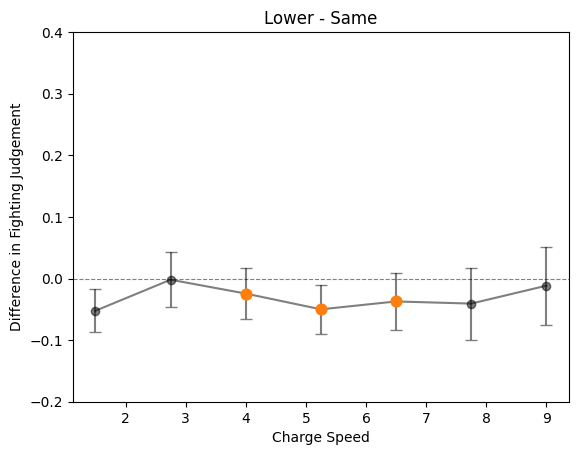

In [27]:
ci = diff.groupby('chargeSpeed')['is_fight_low_same'].agg(['sem', 'count'])
ci['ci95'] = ci['sem'] * stat.t.ppf(0.975, ci['count'] - 1)
diff_mean['ci95'] = ci['ci95'].values

mid = diff_mean['chargeSpeed'].isin([4, 5.25, 6.5])        

plt.axhline(0, color='gray', lw=0.8, ls='--')           
plt.errorbar(diff_mean['chargeSpeed'], diff_mean['is_fight_low_same'],
             yerr=diff_mean['ci95'], color='black', marker='o',
             alpha=0.5, capsize=4)                          
plt.scatter(diff_mean.loc[mid, 'chargeSpeed'], diff_mean.loc[mid, 'is_fight_low_same'],
            color='tab:orange', s=60, zorder=5)

plt.ylim(-0.2, 0.4)
plt.xlabel('Charge Speed')
plt.ylabel('Difference in Fighting Judgement')
plt.title('Lower - Same')

In [28]:
intermediate_speeds_mean = id_mean[id_mean['chargeSpeed'].isin([4, 5.25, 6.5])].groupby(['id', 'soundCondition'])[['is_fight']].mean().reset_index()
intermediate_speeds_mean = intermediate_speeds_mean[intermediate_speeds_mean['soundCondition'] != 'same']
extreme_speeds_mean = id_mean[~id_mean['chargeSpeed'].isin([4, 5.25, 6.5])].groupby(['id', 'soundCondition'])[['is_fight']].mean().reset_index()
extreme_speeds_mean = extreme_speeds_mean[extreme_speeds_mean['soundCondition'] != 'same']

In [29]:
intermediate = pg.pairwise_tests(
    dv='is_fight',
    within='soundCondition',
    subject='id',
    data=intermediate_speeds_mean,
    effsize='cohen'
)
print(intermediate)

         Contrast       A      B  Paired  Parametric         T   dof  \
0  soundCondition  higher  lower    True        True  7.779226  85.0   

  alternative         p-unc      BF10     cohen  
0   two-sided  1.571342e-11  5.62e+08  1.064508  


In [30]:
extreme = pg.pairwise_tests(
    dv='is_fight',
    within='soundCondition',
    subject='id',
    data=extreme_speeds_mean,
    effsize='cohen'
)
print(extreme)

         Contrast       A      B  Paired  Parametric        T   dof  \
0  soundCondition  higher  lower    True        True  5.73889  85.0   

  alternative         p-unc       BF10     cohen  
0   two-sided  1.433490e-07  9.065e+04  0.964864  


### confidence-weighted judgement

In [31]:
c = experiment_df["confidence"] / 100
experiment_df["weighted_is_fight"] = np.where(
    experiment_df["is_fight"] == 1,
    0.5 + c * 0.5,
    0.5 - c * 0.5,
)

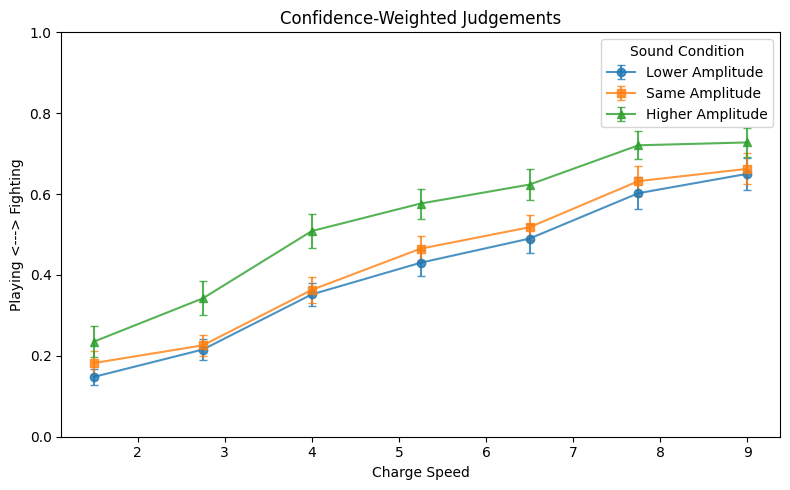

In [32]:
fig, ax = plt.subplots(figsize=(8, 5))

conditions = [
    ('lower',  'Lower Amplitude',  'o'),
    ('same',   'Same Amplitude',   's'),
    ('higher', 'Higher Amplitude', '^'),
]

subj = 'subject_id' 

for cond, label, marker in conditions:
    sub = experiment_df[experiment_df['soundCondition'] == cond]

    # per-subject proportion
    per_subj = (sub.groupby([subj, 'chargeSpeed'])['weighted_is_fight']
                   .mean().reset_index())

    agg = (per_subj.groupby('chargeSpeed')['weighted_is_fight']
                   .agg(m='mean', s='sem', n='count').reset_index())

    # 95% CI half-width via t (per speed, since n can vary)
    agg['ci'] = agg['s'] * stat.t.ppf(0.975, agg['n'] - 1)

    ax.errorbar(agg['chargeSpeed'], agg['m'], yerr=agg['ci'],
                marker=marker, capsize=3, alpha = 0.8, label=label)

ax.set_xlabel('Charge Speed')
ax.set_ylabel('Playing <---> Fighting')
ax.set_ylim(0, 1)
ax.set_title('Confidence-Weighted Judgements')
ax.legend(title='Sound Condition')
plt.tight_layout()
plt.show()

In [33]:
id_weighted_mean = experiment_df.groupby(['id', 'soundCondition', 'chargeSpeed'])[['weighted_is_fight']].mean().reset_index()

In [34]:
anova = pg.rm_anova(dv='weighted_is_fight', within=['soundCondition', 'chargeSpeed'], subject='id', data=id_weighted_mean)
print(anova)

                         Source         SS  ddof1  ddof2        MS  \
0                soundCondition   4.965302      2    170  2.482651   
1                   chargeSpeed  53.943028      6    510  8.990505   
2  soundCondition * chargeSpeed   0.340836     12   1020  0.028403   

            F          p-unc     p-GG-corr       ng2       eps  
0   48.807419   1.777429e-17  2.166802e-12  0.097741  0.661500  
1  277.811212  3.711649e-157  1.020222e-54  0.540629  0.336045  
2    3.160457   1.909892e-04  2.246991e-02  0.007381  0.266947  


In [35]:
posthoc_sound = pg.pairwise_tests(
    dv='weighted_is_fight',
    within='soundCondition',
    subject='id',
    data=id_weighted_mean,
    padjust='bonf',
    effsize='cohen'
)
print(posthoc_sound)

         Contrast       A      B  Paired  Parametric         T   dof  \
0  soundCondition  higher  lower    True        True  7.494369  85.0   
1  soundCondition  higher   same    True        True  7.071096  85.0   
2  soundCondition   lower   same    True        True -3.103664  85.0   

  alternative         p-unc        p-corr p-adjust       BF10     cohen  
0   two-sided  5.829833e-11  1.748950e-10     bonf   1.59e+08  1.060345  
1   two-sided  4.023314e-10  1.206994e-09     bonf  2.482e+07  0.891305  
2   two-sided  2.595677e-03  7.787032e-03     bonf       9.98 -0.244703  


## confidence

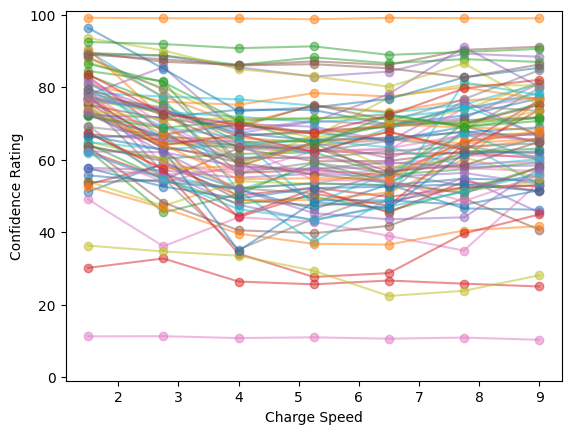

In [36]:
for id in kept_id:
    df = experiment_df[experiment_df['id'] == id]
    mean_rating_per_speed = pd.DataFrame(df.groupby('chargeSpeed')['confidence'].mean().reset_index())
    plt.plot(mean_rating_per_speed['chargeSpeed'], mean_rating_per_speed['confidence'], marker='o', alpha=0.5)
    plt.ylim(-1, 101)
    plt.xlabel('Charge Speed')
    plt.ylabel('Confidence Rating')

Text(0, 0.5, 'Confidence Rating')

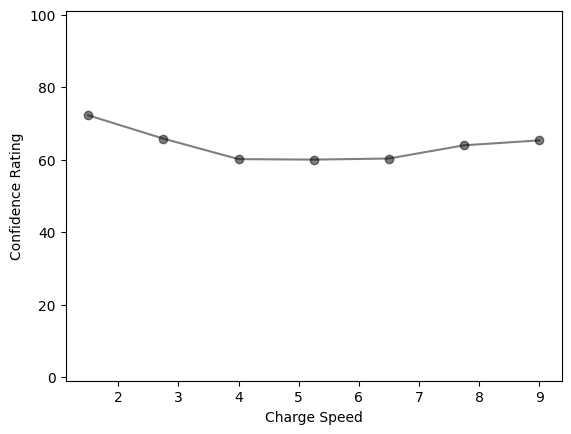

In [37]:
mean_confidence = pd.DataFrame(experiment_df.groupby('chargeSpeed')['confidence'].mean().reset_index())
plt.plot(mean_confidence['chargeSpeed'], mean_confidence['confidence'], color='black', marker='o', alpha=0.5)
plt.ylim(-1, 101)
plt.xlabel('Charge Speed')
plt.ylabel('Confidence Rating')

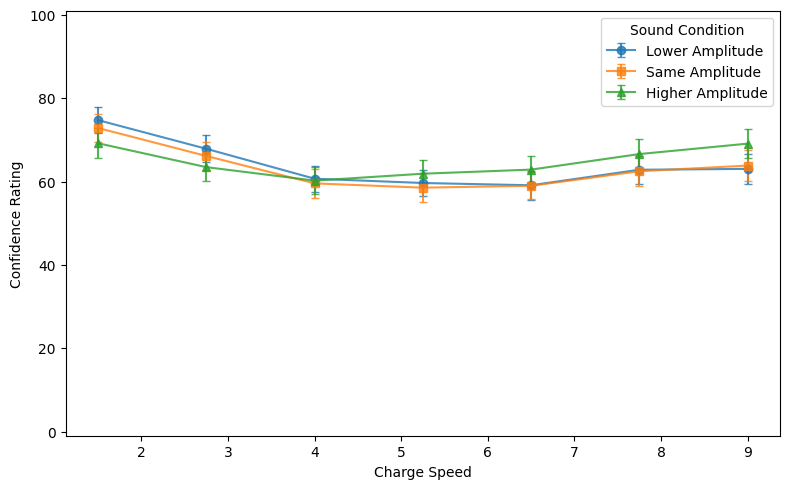

In [38]:
fig, ax = plt.subplots(figsize=(8, 5))

conditions = [
    ('lower',  'Lower Amplitude',  'o'),
    ('same',   'Same Amplitude',   's'),
    ('higher', 'Higher Amplitude', '^'),
]

subj = 'subject_id' 

for cond, label, marker in conditions:
    sub = experiment_df[experiment_df['soundCondition'] == cond]

    # per-subject proportion
    per_subj = (sub.groupby([subj, 'chargeSpeed'])['confidence']
                   .mean().reset_index())

    agg = (per_subj.groupby('chargeSpeed')['confidence']
                   .agg(m='mean', s='sem', n='count').reset_index())

    # 95% CI half-width via t (per speed, since n can vary)
    agg['ci'] = agg['s'] * stat.t.ppf(0.975, agg['n'] - 1)

    ax.errorbar(agg['chargeSpeed'], agg['m'], yerr=agg['ci'],
                marker=marker, capsize=3, alpha = 0.8, label=label)

ax.set_xlabel('Charge Speed')
ax.set_ylabel('Confidence Rating')
ax.set_ylim(-1, 101)
ax.legend(title='Sound Condition')
plt.tight_layout()
plt.show()

In [39]:
anova = pg.rm_anova(dv='confidence', within=['soundCondition', 'chargeSpeed'], subject='id', data=id_mean)
print(anova)

                         Source            SS  ddof1  ddof2           MS  \
0                soundCondition    734.320941      2    170   367.160470   
1                   chargeSpeed  30274.856296      6    510  5045.809383   
2  soundCondition * chargeSpeed   5632.998016     12   1020   469.416501   

           F         p-unc     p-GG-corr       ng2       eps  
0   4.568578  1.167820e-02  1.535688e-02  0.001654  0.876723  
1  54.029843  1.624836e-51  1.395946e-26  0.063921  0.490075  
2  10.371645  1.545333e-19  2.386259e-09  0.012546  0.413690  


In [40]:
posthoc_sound = pg.pairwise_tests(
    dv='confidence',
    within='soundCondition',
    subject='id',
    data=id_mean,
    padjust='bonf',
    effsize='cohen'
)
print(posthoc_sound)

         Contrast       A      B  Paired  Parametric         T   dof  \
0  soundCondition  higher  lower    True        True  1.771904  85.0   
1  soundCondition  higher   same    True        True  2.602309  85.0   
2  soundCondition   lower   same    True        True  1.577740  85.0   

  alternative     p-unc    p-corr p-adjust   BF10     cohen  
0   two-sided  0.079994  0.239982     bonf  0.531  0.056439  
1   two-sided  0.010923  0.032769     bonf   2.81  0.109784  
2   two-sided  0.118340  0.355020     bonf  0.391  0.056140  


In [41]:
posthoc_interaction = pg.pairwise_tests(
    dv='confidence',
    within=['soundCondition', 'chargeSpeed'],
    subject='id',
    data=id_mean,
    padjust='bonf',
    effsize='cohen'
)
print(posthoc_interaction)

                        Contrast soundCondition       A      B Paired  \
0                 soundCondition              -  higher  lower   True   
1                 soundCondition              -  higher   same   True   
2                 soundCondition              -   lower   same   True   
3                    chargeSpeed              -     1.5   2.75   True   
4                    chargeSpeed              -     1.5    4.0   True   
..                           ...            ...     ...    ...    ...   
82  soundCondition * chargeSpeed           same    5.25   7.75   True   
83  soundCondition * chargeSpeed           same    5.25    9.0   True   
84  soundCondition * chargeSpeed           same     6.5   7.75   True   
85  soundCondition * chargeSpeed           same     6.5    9.0   True   
86  soundCondition * chargeSpeed           same    7.75    9.0   True   

   Parametric          T   dof alternative         p-unc        p-corr  \
0        True   1.771904  85.0   two-sided  7.999

### intermediate confidence

Text(0.5, 1.0, 'Higher - Lower')

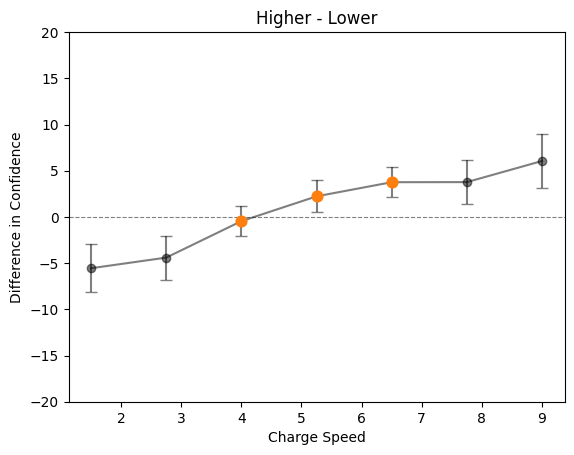

In [42]:
ci = diff.groupby('chargeSpeed')['confidence_high_low'].agg(['sem', 'count'])
ci['ci95'] = ci['sem'] * stat.t.ppf(0.975, ci['count'] - 1)
diff_mean['ci95'] = ci['ci95'].values

mid = diff_mean['chargeSpeed'].isin([4, 5.25, 6.5])        

plt.axhline(0, color='gray', lw=0.8, ls='--')           
plt.errorbar(diff_mean['chargeSpeed'], diff_mean['confidence_high_low'],
             yerr=diff_mean['ci95'], color='black', marker='o',
             alpha=0.5, capsize=4)                          
plt.scatter(diff_mean.loc[mid, 'chargeSpeed'], diff_mean.loc[mid, 'confidence_high_low'],
            color='tab:orange', s=60, zorder=5)

plt.ylim(-20, 20)
plt.xlabel('Charge Speed')
plt.ylabel('Difference in Confidence')
plt.title('Higher - Lower')

In [43]:
intermediate_extreme = pg.pairwise_tests(
    dv='confidence_high_low',
    within='speed_class',
    subject='id',
    data=diff,
    padjust='bonf',
    effsize='cohen'
)
print(intermediate_extreme)

      Contrast        A             B  Paired  Parametric       T   dof  \
0  speed_class  extreme  intermediate    True        True -2.3502  85.0   

  alternative    p-unc   BF10     cohen  
0   two-sided  0.02108  1.596 -0.341814  


Text(0.5, 1.0, 'Higher - Same')

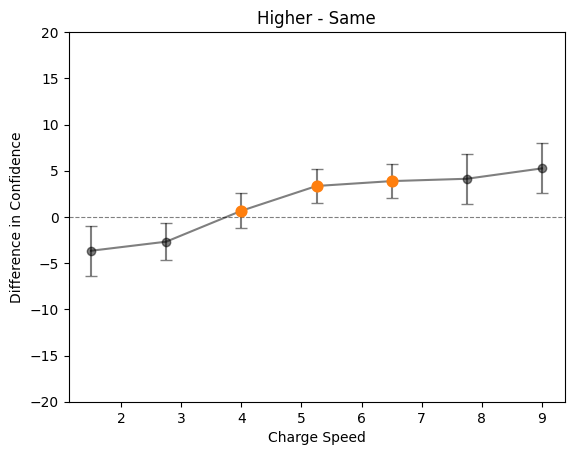

In [44]:
ci = diff.groupby('chargeSpeed')['confidence_high_same'].agg(['sem', 'count'])
ci['ci95'] = ci['sem'] * stat.t.ppf(0.975, ci['count'] - 1)
diff_mean['ci95'] = ci['ci95'].values

mid = diff_mean['chargeSpeed'].isin([4, 5.25, 6.5])        

plt.axhline(0, color='gray', lw=0.8, ls='--')           
plt.errorbar(diff_mean['chargeSpeed'], diff_mean['confidence_high_same'],
             yerr=diff_mean['ci95'], color='black', marker='o',
             alpha=0.5, capsize=4)                          
plt.scatter(diff_mean.loc[mid, 'chargeSpeed'], diff_mean.loc[mid, 'confidence_high_same'],
            color='tab:orange', s=60, zorder=5)

plt.ylim(-20, 20)
plt.xlabel('Charge Speed')
plt.ylabel('Difference in Confidence')
plt.title('Higher - Same')

Text(0.5, 1.0, 'Lower - Same')

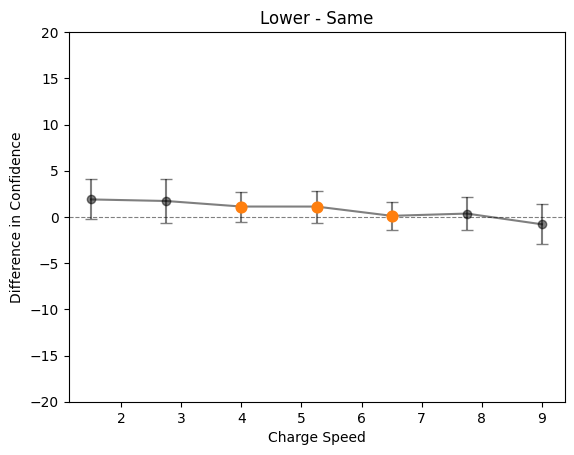

In [45]:
ci = diff.groupby('chargeSpeed')['confidence_low_same'].agg(['sem', 'count'])
ci['ci95'] = ci['sem'] * stat.t.ppf(0.975, ci['count'] - 1)
diff_mean['ci95'] = ci['ci95'].values

mid = diff_mean['chargeSpeed'].isin([4, 5.25, 6.5])        

plt.axhline(0, color='gray', lw=0.8, ls='--')           
plt.errorbar(diff_mean['chargeSpeed'], diff_mean['confidence_low_same'],
             yerr=diff_mean['ci95'], color='black', marker='o',
             alpha=0.5, capsize=4)                          
plt.scatter(diff_mean.loc[mid, 'chargeSpeed'], diff_mean.loc[mid, 'confidence_low_same'],
            color='tab:orange', s=60, zorder=5)

plt.ylim(-20, 20)
plt.xlabel('Charge Speed')
plt.ylabel('Difference in Confidence')
plt.title('Lower - Same')

In [46]:
intermediate_confidence_mean = id_mean[id_mean['chargeSpeed'].isin([4, 5.25, 6.5])].groupby(['id', 'soundCondition'])[['confidence']].mean().reset_index()
intermediate_confidence_mean = intermediate_confidence_mean[intermediate_confidence_mean['soundCondition'] != 'same']
slow_confidence_mean = id_mean[id_mean['chargeSpeed'].isin([1.5, 2.75])].groupby(['id', 'soundCondition'])[['confidence']].mean().reset_index()
fast_confidence_mean = id_mean[id_mean['chargeSpeed'].isin([7.75, 9])].groupby(['id', 'soundCondition'])[['confidence']].mean().reset_index()
slow_confidence_mean = slow_confidence_mean[slow_confidence_mean['soundCondition'] != 'same']
fast_confidence_mean = fast_confidence_mean[fast_confidence_mean['soundCondition'] != 'same']

In [47]:
intermediate = pg.pairwise_tests(
    dv='confidence',
    within='soundCondition',
    subject='id',
    data=intermediate_confidence_mean,
    effsize='cohen'
)
print(intermediate)

         Contrast       A      B  Paired  Parametric         T   dof  \
0  soundCondition  higher  lower    True        True  2.951584  85.0   

  alternative     p-unc   BF10     cohen  
0   two-sided  0.004085  6.664  0.126065  


In [48]:
slow = pg.pairwise_tests(
    dv='confidence',
    within='soundCondition',
    subject='id',
    data=slow_confidence_mean,
    effsize='cohen'
)
print(slow)

         Contrast       A      B  Paired  Parametric        T   dof  \
0  soundCondition  higher  lower    True        True -4.90274  85.0   

  alternative     p-unc      BF10     cohen  
0   two-sided  0.000004  3506.583 -0.342409  


In [49]:
fast = pg.pairwise_tests(
    dv='confidence',
    within='soundCondition',
    subject='id',
    data=fast_confidence_mean,
    effsize='cohen'
)
print(fast)

         Contrast       A      B  Paired  Parametric         T   dof  \
0  soundCondition  higher  lower    True        True  4.324074  85.0   

  alternative     p-unc     BF10     cohen  
0   two-sided  0.000041  438.462  0.315457  


# main analysis - within sound conditions

## ISI check

In [50]:
isi = pd.DataFrame(experiment_df.groupby(['id', 'soundCondition'])['ISI_ms'].mean()).reset_index()
aov = pg.rm_anova(data=isi, dv='ISI_ms', within='soundCondition', subject='id')
print(aov)

           Source  ddof1  ddof2         F     p-unc       ng2       eps
0  soundCondition      2    170  0.151543  0.859497  0.000675  0.991086


## judgement

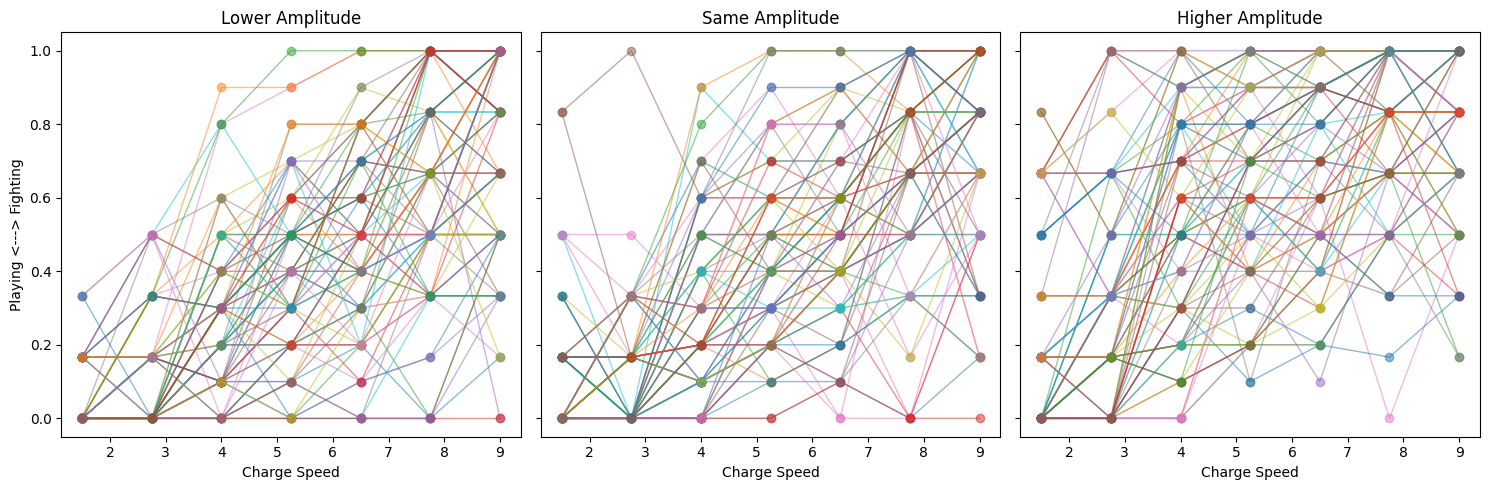

In [51]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

conditions = [
    ('lower',  'Lower Amplitude',  'o'),
    ('same',   'Same Amplitude',   'o'),
    ('higher', 'Higher Amplitude', 'o'),
]

for ax, (cond, title, marker) in zip(axes, conditions):
    sub = experiment_df[experiment_df['soundCondition'] == cond]

    # One line per participant
    for pid in kept_id:
        p = sub[sub['id'] == pid]
        means = p.groupby('chargeSpeed')['is_fight'].mean().reset_index()
        ax.plot(means['chargeSpeed'], means['is_fight'],
                marker=marker, alpha=0.5, linewidth=1)

    ax.set_title(title)
    ax.set_xlabel('Charge Speed')


axes[0].set_ylabel('Playing <---> Fighting')
plt.tight_layout()
plt.show()

In [52]:
per_pid = (experiment_df
           .groupby(['id', 'soundCondition', 'chargeSpeed'])['is_fight']
           .mean()
           .reset_index())

order = ['lower', 'same', 'higher']
speeds = sorted(per_pid['chargeSpeed'].unique())
ids = per_pid['id'].unique()

### UNCOMMENT TO PLOT PER PARTICIPANT
# for pid in ids:
#     pdat = per_pid[per_pid['id'] == pid]
#     fig, axes = plt.subplots(1, len(speeds), figsize=(20, 5), sharey=True)

#     for ax, speed in zip(axes, speeds):
#         sub = pdat[pdat['chargeSpeed'] == speed]
#         sns.pointplot(data=sub, x='soundCondition', y='is_fight',
#                       order=order, ax=ax, join=False, color='tab:blue')
#         ax.set_title(f'Speed {speed}')
#         ax.set_xlabel('')
#         ax.set_ylim(-0.05, 1.05)
#         ax.tick_params(axis='x', rotation=45)

#     axes[0].set_ylabel('Playing <---> Fighting')
#     fig.supxlabel(pid)
#     plt.tight_layout()
#     plt.show()

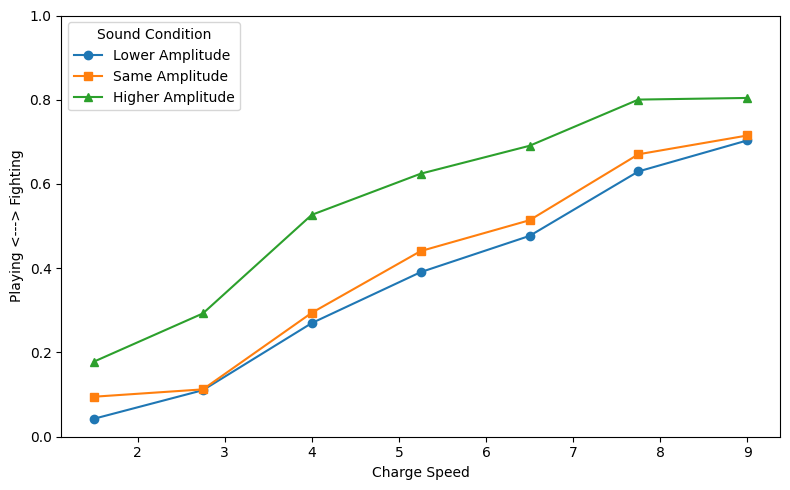

In [53]:
pythonfig, ax = plt.subplots(figsize=(8, 5))

conditions = [
    ('lower',  'Lower Amplitude',  'o'),
    ('same',   'Same Amplitude',   's'),
    ('higher', 'Higher Amplitude', '^'),
]

for cond, label, marker in conditions:
    sub = experiment_df[experiment_df['soundCondition'] == cond]
    means = sub.groupby('chargeSpeed')['is_fight'].mean().reset_index()
    ax.plot(means['chargeSpeed'], means['is_fight'],
            marker=marker, label=label)

ax.set_xlabel('Charge Speed')
ax.set_ylabel('Playing <---> Fighting')
ax.set_ylim(0, 1)
ax.legend(title='Sound Condition')
plt.tight_layout()
plt.show()

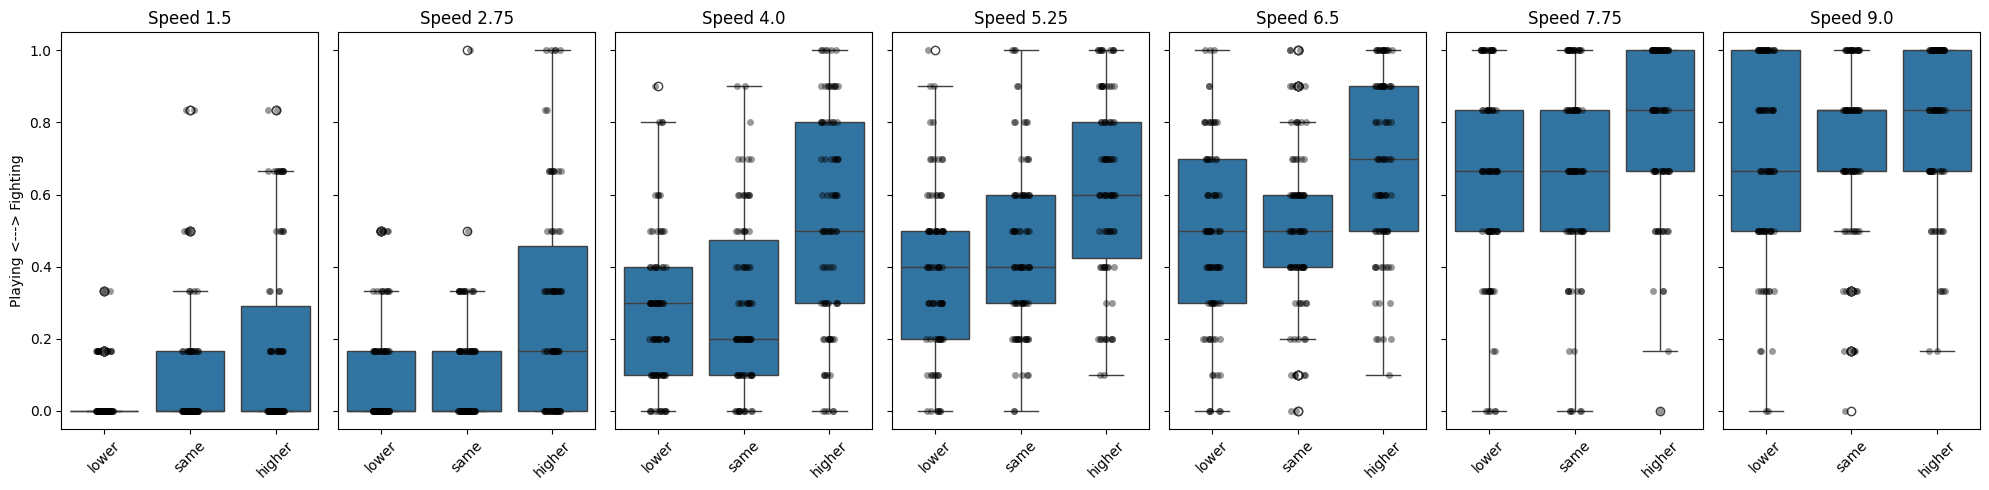

In [54]:
per_pid = (experiment_df
           .groupby(['id', 'soundCondition', 'chargeSpeed'])['is_fight']
           .mean()
           .reset_index())

order = ['lower', 'same', 'higher']
speeds = sorted(per_pid['chargeSpeed'].unique())

fig, axes = plt.subplots(1, len(speeds), figsize=(20, 5), sharey=True)

for ax, speed in zip(axes, speeds):
    sub = per_pid[per_pid['chargeSpeed'] == speed]
    sns.boxplot(data=sub, x='soundCondition', y='is_fight', order=order, ax=ax)
    sns.stripplot(data=sub, x='soundCondition', y='is_fight',
                  order=order, ax=ax, color='black', alpha=0.4, jitter=True)
    ax.set_title(f'Speed {speed}')
    ax.set_xlabel('')
    ax.set_ylim(-0.05, 1.05)
    ax.tick_params(axis='x', rotation=45)

axes[0].set_ylabel('Playing <---> Fighting')
plt.tight_layout()
plt.show()

## confidence

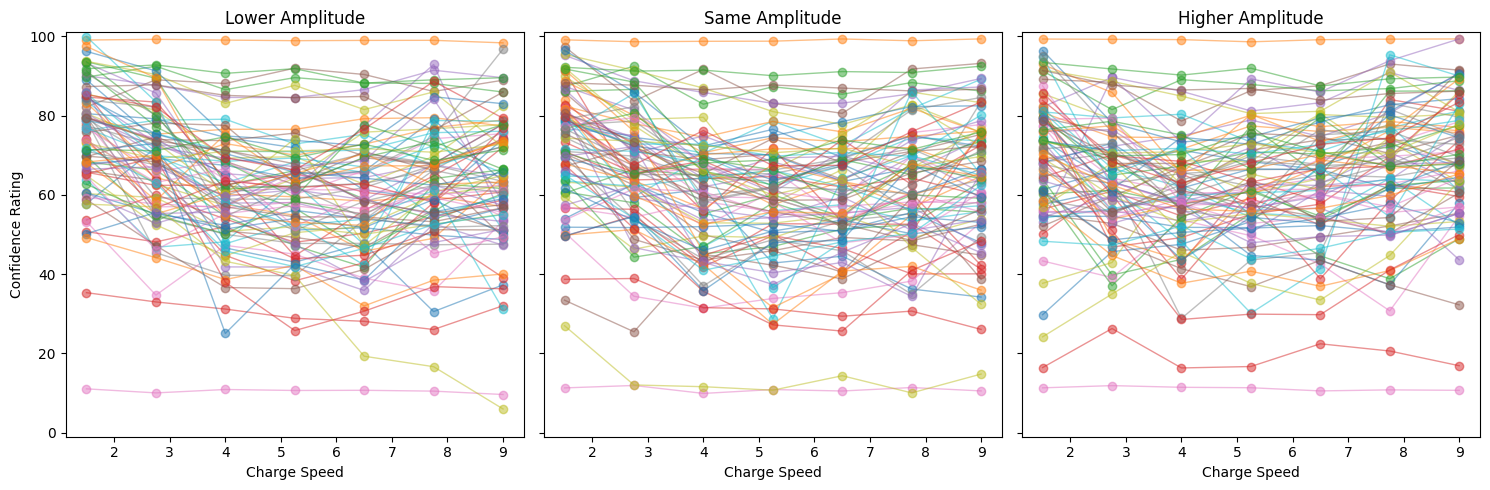

In [55]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

conditions = [
    ('lower',  'Lower Amplitude',  'o'),
    ('same',   'Same Amplitude',   'o'),
    ('higher', 'Higher Amplitude', 'o'),
]

for ax, (cond, title, marker) in zip(axes, conditions):
    sub = experiment_df[experiment_df['soundCondition'] == cond]
    for pid in kept_id:
        p = sub[sub['id'] == pid]
        means = p.groupby('chargeSpeed')['confidence'].mean().reset_index()
        ax.plot(means['chargeSpeed'], means['confidence'],
                marker=marker, alpha=0.5, linewidth=1)

    ax.set_title(title)
    ax.set_xlabel('Charge Speed')
    ax.set_ylim(-1, 101)


axes[0].set_ylabel('Confidence Rating')
plt.tight_layout()
plt.show()

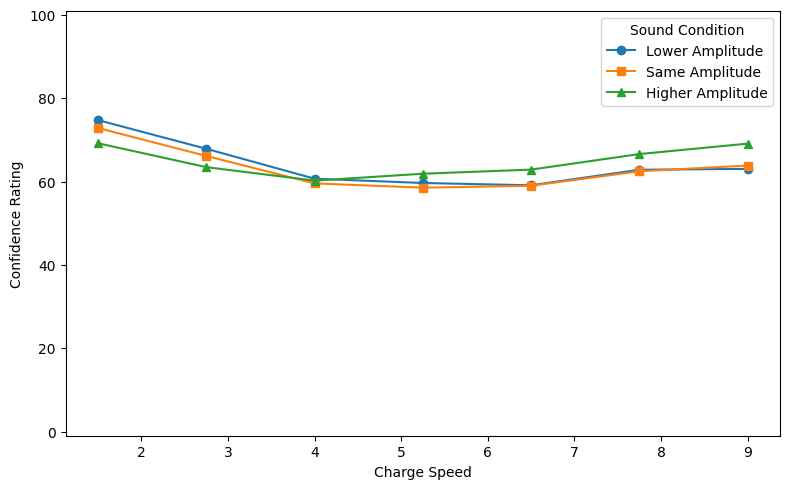

In [56]:
pythonfig, ax = plt.subplots(figsize=(8, 5))

conditions = [
    ('lower',  'Lower Amplitude',  'o'),
    ('same',   'Same Amplitude',   's'),
    ('higher', 'Higher Amplitude', '^'),
]

for cond, label, marker in conditions:
    sub = experiment_df[experiment_df['soundCondition'] == cond]
    means = sub.groupby('chargeSpeed')['confidence'].mean().reset_index()
    ax.plot(means['chargeSpeed'], means['confidence'],
            marker=marker, label=label)

ax.set_xlabel('Charge Speed')
ax.set_ylabel('Confidence Rating')
ax.set_ylim(-1, 101)
ax.legend(title='Sound Condition')
plt.tight_layout()
plt.show()

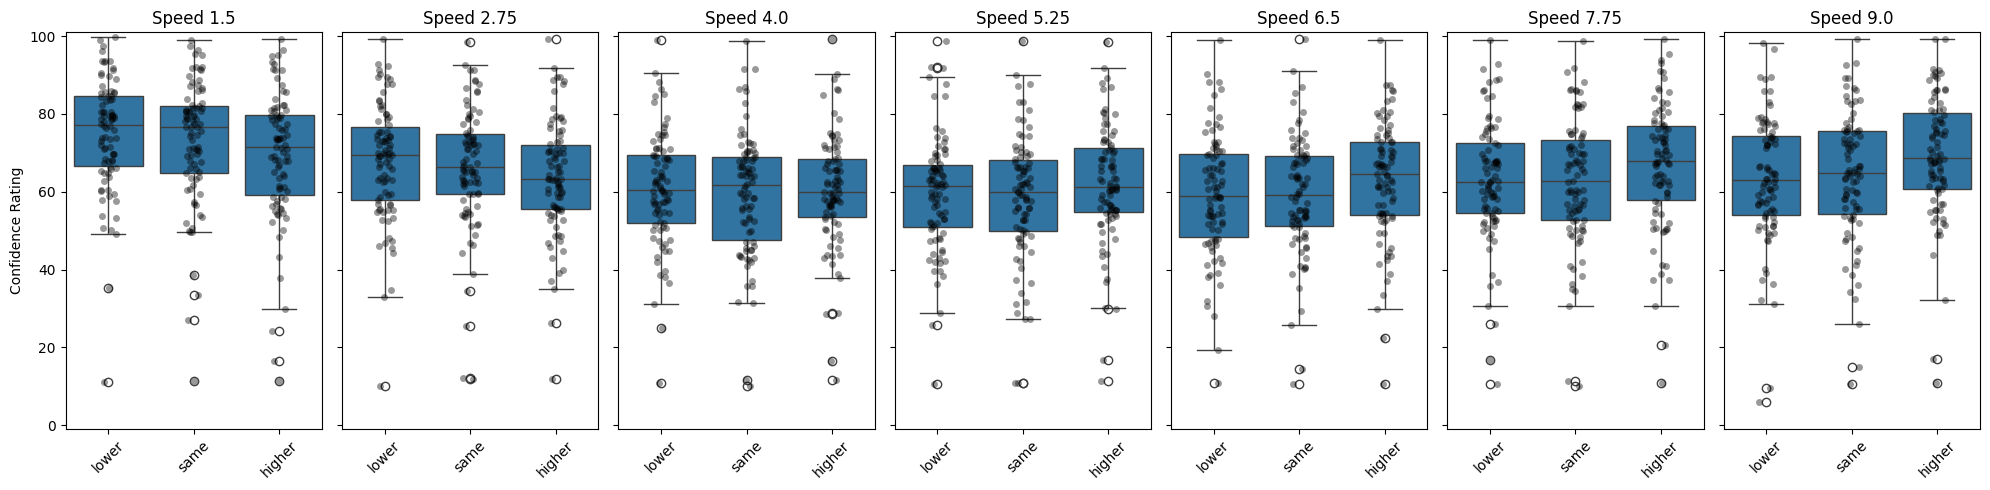

In [57]:
per_pid = (experiment_df
           .groupby(['id', 'soundCondition', 'chargeSpeed'])['confidence']
           .mean()
           .reset_index())

order = ['lower', 'same', 'higher']
speeds = sorted(per_pid['chargeSpeed'].unique())

fig, axes = plt.subplots(1, len(speeds), figsize=(20, 5), sharey=True)

for ax, speed in zip(axes, speeds):
    sub = per_pid[per_pid['chargeSpeed'] == speed]
    sns.boxplot(data=sub, x='soundCondition', y='confidence', order=order, ax=ax)
    sns.stripplot(data=sub, x='soundCondition', y='confidence',
                  order=order, ax=ax, color='black', alpha=0.4, jitter=True)
    ax.set_title(f'Speed {speed}')
    ax.set_xlabel('')
    ax.set_ylim(-1, 101)
    ax.tick_params(axis='x', rotation=45)

axes[0].set_ylabel('Confidence Rating')
plt.tight_layout()
plt.show()

# Group analysis by sound awareness

### Subjective report

In [58]:
aware_id = []
non_aware_id = []
for i in kept_id:
    sub_demo = demographic_df[demographic_df['subject_id'] == i]
    if 'louder' in sub_demo['sound_awareness'].values[0] and 'softer' in sub_demo['sound_awareness'].values[0]:
        aware_id.append(i)
    else:
        non_aware_id.append(i)

In [59]:
len(aware_id), len(non_aware_id)

(73, 13)

In [60]:
aware_df = experiment_df[experiment_df['subject_id'].isin(aware_id)]
non_aware_df = experiment_df[experiment_df['subject_id'].isin(non_aware_id)]

In [61]:
experiment_df["sound_aware"] = experiment_df["subject_id"].isin(aware_id).astype(int)
experiment_df.to_csv('../data_analysis/exp1_replication_experiment_data.csv', index=False)

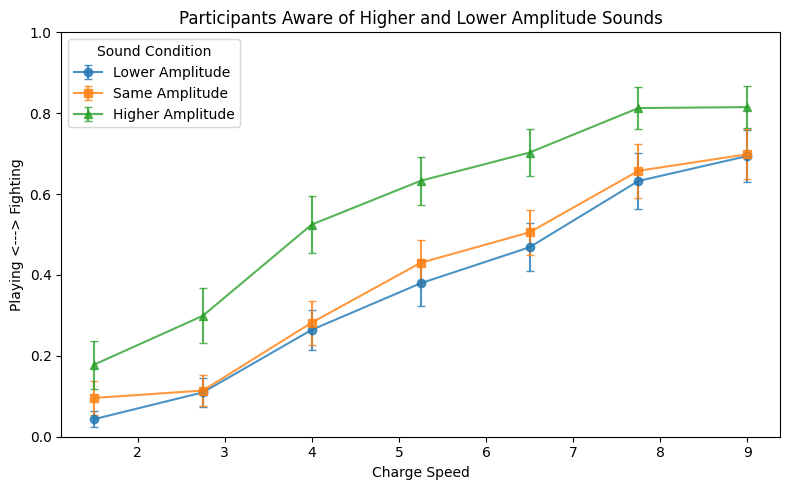

In [62]:
fig, ax = plt.subplots(figsize=(8, 5))

conditions = [
    ('lower',  'Lower Amplitude',  'o'),
    ('same',   'Same Amplitude',   's'),
    ('higher', 'Higher Amplitude', '^'),
]

subj = 'subject_id' 

for cond, label, marker in conditions:
    sub = aware_df[aware_df['soundCondition'] == cond]

    # per-subject proportion
    per_subj = (sub.groupby([subj, 'chargeSpeed'])['is_fight']
                   .mean().reset_index())

    agg = (per_subj.groupby('chargeSpeed')['is_fight']
                   .agg(m='mean', s='sem', n='count').reset_index())

    # 95% CI half-width via t (per speed, since n can vary)
    agg['ci'] = agg['s'] * stat.t.ppf(0.975, agg['n'] - 1)

    ax.errorbar(agg['chargeSpeed'], agg['m'], yerr=agg['ci'],
                marker=marker, capsize=3, alpha = 0.8, label=label)

ax.set_xlabel('Charge Speed')
ax.set_ylabel('Playing <---> Fighting')
ax.set_ylim(0, 1)
ax.set_title('Participants Aware of Higher and Lower Amplitude Sounds')
ax.legend(title='Sound Condition')
plt.tight_layout()
plt.show()

In [63]:
aware_id_mean = aware_df.groupby(['id', 'soundCondition', 'chargeSpeed'])[['is_fight']].mean().reset_index()

In [64]:
anova = pg.rm_anova(dv='is_fight', within=['soundCondition', 'chargeSpeed'], subject='id', data=aware_id_mean)
print(anova)

                         Source         SS  ddof1  ddof2         MS  \
0                soundCondition  11.537199      2    144   5.768600   
1                   chargeSpeed  78.943479      6    432  13.157247   
2  soundCondition * chargeSpeed   0.949954     12    864   0.079163   

            F          p-unc     p-GG-corr       ng2       eps  
0   39.316692   2.374645e-14  1.604042e-10  0.117375  0.680339  
1  219.188003  1.124179e-127  5.278036e-56  0.476425  0.425973  
2    3.554826   3.491736e-05  1.169341e-02  0.010831  0.281046  


In [65]:
posthoc_sound = pg.pairwise_tests(
    dv='is_fight',
    within='soundCondition',
    subject='id',
    data=aware_id_mean,
    padjust='bonf',
    effsize='cohen'
)
print(posthoc_sound)

         Contrast       A      B  Paired  Parametric         T   dof  \
0  soundCondition  higher  lower    True        True  6.684245  72.0   
1  soundCondition  higher   same    True        True  6.551958  72.0   
2  soundCondition   lower   same    True        True -1.953405  72.0   

  alternative         p-unc        p-corr p-adjust       BF10     cohen  
0   two-sided  4.201662e-09  1.260498e-08     bonf  2.708e+06  1.128475  
1   two-sided  7.326099e-09  2.197830e-08     bonf  1.593e+06  0.999142  
2   two-sided  5.465775e-02  1.639732e-01     bonf      0.775 -0.178210  


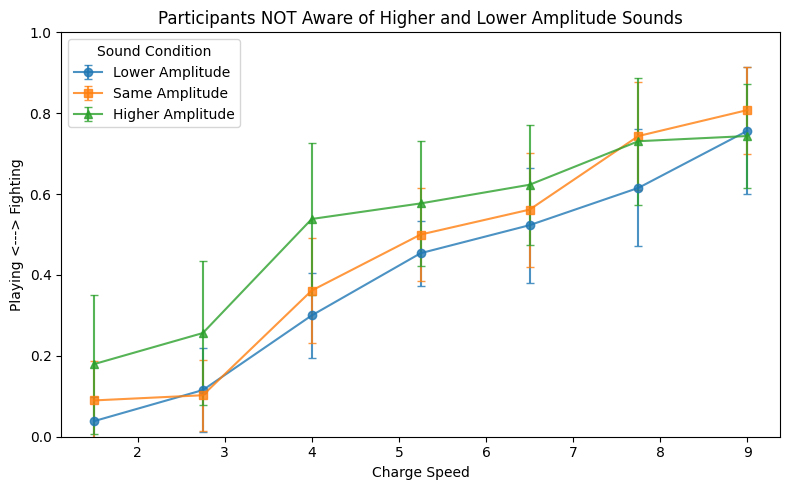

In [66]:
fig, ax = plt.subplots(figsize=(8, 5))

conditions = [
    ('lower',  'Lower Amplitude',  'o'),
    ('same',   'Same Amplitude',   's'),
    ('higher', 'Higher Amplitude', '^'),
]

subj = 'subject_id' 

for cond, label, marker in conditions:
    sub = non_aware_df[non_aware_df['soundCondition'] == cond]

    # per-subject proportion
    per_subj = (sub.groupby([subj, 'chargeSpeed'])['is_fight']
                   .mean().reset_index())

    agg = (per_subj.groupby('chargeSpeed')['is_fight']
                   .agg(m='mean', s='sem', n='count').reset_index())

    # 95% CI half-width via t (per speed, since n can vary)
    agg['ci'] = agg['s'] * stat.t.ppf(0.975, agg['n'] - 1)

    ax.errorbar(agg['chargeSpeed'], agg['m'], yerr=agg['ci'],
                marker=marker, capsize=3, alpha = 0.8, label=label)

ax.set_xlabel('Charge Speed')
ax.set_ylabel('Playing <---> Fighting')
ax.set_ylim(0, 1)
ax.set_title('Participants NOT Aware of Higher and Lower Amplitude Sounds')
ax.legend(title='Sound Condition')
plt.tight_layout()
plt.show()

In [67]:
non_aware_id_mean = non_aware_df.groupby(['id', 'soundCondition', 'chargeSpeed'])[['is_fight']].mean().reset_index()

In [68]:
anova = pg.rm_anova(dv='is_fight', within=['soundCondition', 'chargeSpeed'], subject='id', data=non_aware_id_mean)
print(anova)

                         Source         SS  ddof1  ddof2        MS          F  \
0                soundCondition   0.669141      2     24  0.334571   4.192620   
1                   chargeSpeed  15.152104      6     72  2.525351  39.733238   
2  soundCondition * chargeSpeed   0.377468     12    144  0.031456   1.431559   

          p-unc     p-GG-corr       ng2       eps  
0  2.743908e-02  5.440642e-02  0.051167  0.589622  
1  6.020449e-21  6.007117e-08  0.549773  0.312751  
2  1.579576e-01  2.521424e-01  0.029522  0.230002  


### Objective sound test

In [69]:
sound_check_wide

pair,id,lower_vs_higher,same_vs_higher,same_vs_lower,perceives_higher,perceives_lower,group
0,5b72d3f8afce7600019fe275,1,1,1,True,True,both
1,5c1b9212bfd9220001a9ada0,1,1,1,True,True,both
2,5d510396f6725b001a4fc025,1,1,1,True,True,both
3,5df6818e2b12bd474abc4c9d,1,1,1,True,True,both
4,60c6cd8bacdf5d1f27924048,1,1,1,True,True,both
...,...,...,...,...,...,...,...
81,6a1890bd5df03242eb3ab012,1,1,0,True,False,higher_only
82,6a19ca355494e759ce50d4ec,1,1,1,True,True,both
83,6a2175c360246072eb4a4667,1,1,1,True,True,both
84,6a23a402e4379480fb4d5335,1,1,1,True,True,both


In [70]:
aware_id = []
non_aware_id = []
for i in kept_id:
    if sound_check_wide[sound_check_wide['id'] == i]['group'].values[0] == 'both':
        aware_id.append(i)
    else:
        non_aware_id.append(i)

aware_df = experiment_df[experiment_df['subject_id'].isin(aware_id)]
non_aware_df = experiment_df[experiment_df['subject_id'].isin(non_aware_id)]

In [71]:
len(aware_id), len(non_aware_id)

(82, 4)

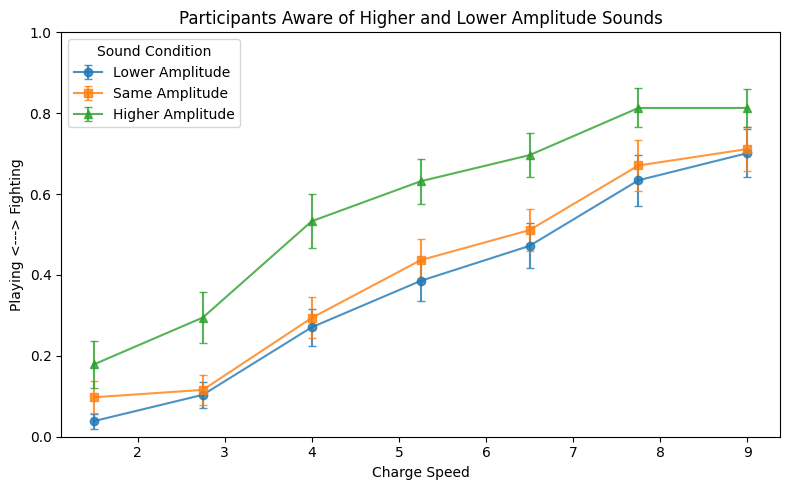

In [72]:
fig, ax = plt.subplots(figsize=(8, 5))

conditions = [
    ('lower',  'Lower Amplitude',  'o'),
    ('same',   'Same Amplitude',   's'),
    ('higher', 'Higher Amplitude', '^'),
]

subj = 'subject_id' 

for cond, label, marker in conditions:
    sub = aware_df[aware_df['soundCondition'] == cond]

    # per-subject proportion
    per_subj = (sub.groupby([subj, 'chargeSpeed'])['is_fight']
                   .mean().reset_index())

    agg = (per_subj.groupby('chargeSpeed')['is_fight']
                   .agg(m='mean', s='sem', n='count').reset_index())

    # 95% CI half-width via t (per speed, since n can vary)
    agg['ci'] = agg['s'] * stat.t.ppf(0.975, agg['n'] - 1)

    ax.errorbar(agg['chargeSpeed'], agg['m'], yerr=agg['ci'],
                marker=marker, capsize=3, alpha = 0.8, label=label)

ax.set_xlabel('Charge Speed')
ax.set_ylabel('Playing <---> Fighting')
ax.set_ylim(0, 1)
ax.set_title('Participants Aware of Higher and Lower Amplitude Sounds')
ax.legend(title='Sound Condition')
plt.tight_layout()
plt.show()

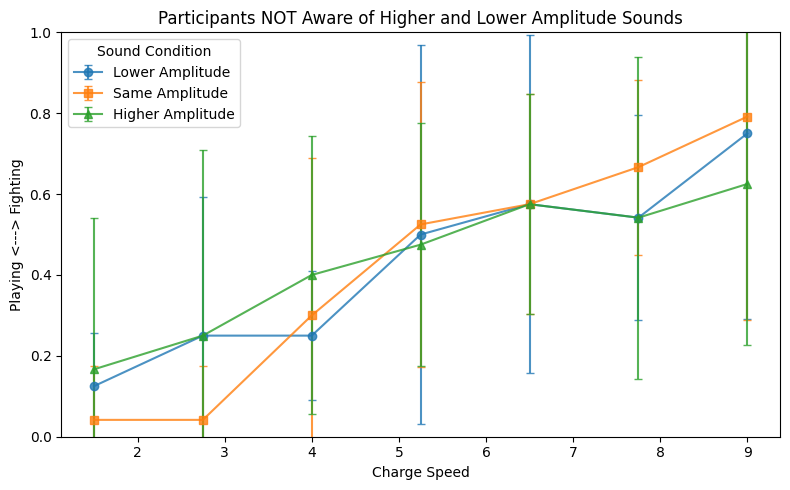

In [73]:
fig, ax = plt.subplots(figsize=(8, 5))

conditions = [
    ('lower',  'Lower Amplitude',  'o'),
    ('same',   'Same Amplitude',   's'),
    ('higher', 'Higher Amplitude', '^'),
]

subj = 'subject_id' 

for cond, label, marker in conditions:
    sub = non_aware_df[non_aware_df['soundCondition'] == cond]

    # per-subject proportion
    per_subj = (sub.groupby([subj, 'chargeSpeed'])['is_fight']
                   .mean().reset_index())

    agg = (per_subj.groupby('chargeSpeed')['is_fight']
                   .agg(m='mean', s='sem', n='count').reset_index())

    # 95% CI half-width via t (per speed, since n can vary)
    agg['ci'] = agg['s'] * stat.t.ppf(0.975, agg['n'] - 1)

    ax.errorbar(agg['chargeSpeed'], agg['m'], yerr=agg['ci'],
                marker=marker, capsize=3, alpha = 0.8, label=label)

ax.set_xlabel('Charge Speed')
ax.set_ylabel('Playing <---> Fighting')
ax.set_ylim(0, 1)
ax.set_title('Participants NOT Aware of Higher and Lower Amplitude Sounds')
ax.legend(title='Sound Condition')
plt.tight_layout()
plt.show()